In [1]:
import os, sys
import cv2
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import MaxPooling2D, Conv2D, Dense, Flatten
import matplotlib.pyplot as plt

def get_data_from_file(train_file):
  train_data = []
  with open(train_file, 'r') as fp:
    lines = fp.readlines()
  for k, line in enumerate(lines):
    print('{:6d} /{:6d}'.format(k + 1, len(lines)), end='\r')
    filename = line.strip()
    img_path = os.path.join('train', filename)
    try:
      img = cv2.imread(img_path)

      if img is None:
        raise ValueError("Cannot read image")

      img_resized = cv2.resize(img, (48, 48))

      if 'cat' in filename:
        label = 0
      elif 'dog' in filename:
        label = 1
      train_data.append([img_resized, label])
    except:
      print()
      print('Error:', img_path)
  return train_data

def get_image_and_label(train_data):
  X_train = []
  Y_train = []
  for data in train_data:
    X_train.append(data[0])
    Y_train.append(data[1])
  X_train = np.array(X_train, dtype=np.uint8)
  Y_train = np.array(Y_train, dtype=np.uint8)
  return X_train, Y_train

def assignment4b_1():
  train_file = 'train_list.txt'
  test_file = 'test_list.txt'
  train_data = get_data_from_file(train_file)
  X_train, Y_train = get_image_and_label(train_data)
  print()  
  test_data = get_data_from_file(test_file)
  X_test, Y_test = get_image_and_label(test_data)
  print()
  print(len(train_data))
  print(train_data[0][0].shape)
  print(len(test_data))
  print(test_data[0][0].shape)

  save_path = 'dogs_cats.pkl'
  print('Saving to', save_path)
  data = {}
  data['X_train'] = X_train
  data['Y_train'] = Y_train
  data['X_test'] = X_test
  data['Y_test'] = Y_test
  pickle.dump(data, open(save_path, 'wb'))

def build_model():
  model = keras.Sequential()
  model.add(keras.layers.InputLayer(input_shape=(48, 48, 3)))
  model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(2, activation='softmax'))

  return model

def assignment4b_2():
  data = pickle.load(open("dogs_cats.pkl","rb"))
  X_train, Y_train, X_test, Y_test = data["X_train"], data["Y_train"], data["X_test"], data["Y_test"]
  X_train = X_train / 255.0
  X_test = X_test / 255.0
  model = build_model()
  model.summary()
  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  ck_dir = "ckpt_dogcat"
  checkpoint_path = ck_dir+"/cp-{epoch:04d}.ckpt"
  cp_callback = keras.callbacks.ModelCheckpoint(checkpoint_path, save_weights_only=True, verbose=1, period=10)
  batch_size = 64
  epochs = 60
  history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, callbacks=[cp_callback], validation_split=0.1, shuffle=True)
  test_loss, test_acc = model.evaluate(X_test, Y_test)
  print("Test accuracy:", test_acc)
  pickle.dump(history.history, open("history.pkl", "wb"))
    
def assignment4b_3():
  history = pickle.load(open("history.pkl", "rb"))
  plt.figure()
  plt.plot(history['accuracy'], label='train')
  plt.plot(history['val_accuracy'], label='val')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()
  plt.figure()
  plt.plot(history['loss'], label='train')
  plt.plot(history['val_loss'], label='val')
  plt.xlabel('epoch')
  plt.ylabel('loss')
  plt.legend()
  plt.grid(True)
  plt.show()

def assignment4b_4():
  data = pickle.load(open("dogs_cats.pkl", "rb"))
  X_test = data["X_test"]
  Y_test = data["Y_test"]
  X_test = X_test / 255.0
  accuracies = {}
  for epoch in [10, 20, 30, 40, 50, 60]:
    model = build_model()
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    weight_path = "ckpt_dogcat/cp-{:04d}.ckpt".format(epoch)
    model.load_weights(weight_path)
    loss, acc = model.evaluate(X_test, Y_test, verbose=0)
    accuracies[epoch] = acc
    print("Epoch {}: test accuracy = {:.4f}".format(epoch, acc))
  best_epoch = max(accuracies, key=accuracies.get)
  best_acc = accuracies[best_epoch]
  print("Best epoch:", best_epoch)
  print("Highest test accuracy:", best_acc)


In [2]:
if __name__ == '__main__':
    assignment4b_1() # do not modify this line

 20000 / 20000
  5000 /  5000
20000
(48, 48, 3)
5000
(48, 48, 3)
Saving to dogs_cats.pkl


In [3]:
    assignment4b_2() # do not modify this line

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 32)          0

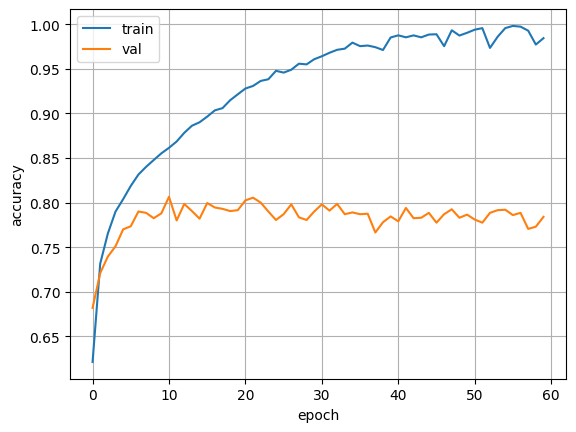

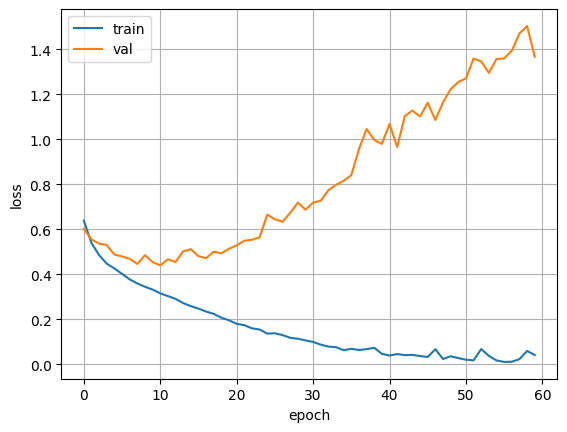

In [4]:
    assignment4b_3() # do not modify this line

In [5]:
    assignment4b_4() # do not modify this line

Epoch 10: test accuracy = 0.8190
Epoch 20: test accuracy = 0.8246
Epoch 30: test accuracy = 0.8230
Epoch 40: test accuracy = 0.8154
Epoch 50: test accuracy = 0.8150
Epoch 60: test accuracy = 0.8014
Best epoch: 20
Highest test accuracy: 0.8245999813079834


In [ ]:
# Question 1 (5 points): If we set shuffle=False during the execution of model.fit() in Assignment 4b-2,
# which was previously set to shuffle=True, what impact will this have on the validation accuracy?
當shuffle=False時，訓練資料在 model.fit() 過程中不會被打亂。
shuffle主要影響的是每個epoch訓練資料餵進model的順序。
若shuffle=False，mini-batch的資料順序固定，如果原始資料排列有規律，訓練會比較不穩定

In [ ]:
# Question 2 (5 points): In Assignment 4b-4, what epoch yields the highest test accuracy, and what is the reason for this?
20，最後一個epoch不一定會有最好的test accuracy。
訓練進行過程中training accuracy可能會持續上升，但test accuracy可能會因為overfitting下降。